# 01 — What is Machine Learning?
**Goal:** Establish the vocabulary and taxonomy of the field before any
math. Sources: ISLR Ch1, Géron Ch1, Mitchell (1997).

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/learning_courses')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_diabetes, make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print('numpy     ', np.__version__)
print('pandas    ', pd.__version__)

numpy      2.5.0
pandas     3.0.3


## 1. Mitchell's definition (1997)

> A computer program is said to *learn* from experience **E** with respect to
> some class of tasks **T** and performance measure **P** if its performance
> at tasks in T, as measured by P, improves with experience E.

Every ML problem can be written as a triple **(T, E, P)**:

| Element | Example (spam filter) |
|---|---|
| Task T | classify an email as spam / not spam |
| Experience E | a corpus of labeled emails |
| Performance P | accuracy, precision, recall |

If you cannot name T, E, P for your problem, you do not yet have a learning
problem — you have a wish.

## 2. The taxonomy

```
                         Machine learning
              ┌─────────────┬─────────────┬────────────┐
          Supervised   Unsupervised   Reinforcement
              │             │             │
      ┌───────┴──────┐   ┌──┴───┐   ┌────┴────┐
  Classification  Regression  Clustering   Agent / env
      │             │         Dimensionality  │
      │             │         reduction       │
      │             │         Density         │
      │             │         Anomaly          │
```

**Supervised** — every example has a label. Predict y from x.
**Unsupervised** — no labels. Find structure in x.
**Reinforcement** — no labels, but delayed reward from an environment.

In practice ~80% of industry work is supervised, ~15% unsupervised, ~5% RL.

## 3. A first concrete example — classification on Iris

The Iris dataset (Fisher 1936, used by every ML textbook since) has 150
flowers, each with 4 measurements, labeled with one of 3 species. We will
train a logistic regression to predict the species from the measurements.

In [2]:
iris = load_iris()
X, y = iris.data, iris.target
print('shape X:', X.shape, '| shape y:', y.shape)
print('classes :', iris.target_names)
print('first 3 :')
pd.DataFrame(X[:3], columns=iris.feature_names)

shape X: (150, 4) | shape y: (150,)
classes : ['setosa' 'versicolor' 'virginica']
first 3 :


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
clf = LogisticRegression(max_iter=200).fit(X_train, y_train)
acc = accuracy_score(y_test, clf.predict(X_test))
print(f'Accuracy on held-out test set: {acc:.3f}')

Accuracy on held-out test set: 0.947


## 4. Three things just happened

1. **Train / test split** (75% / 25%) — we held out data the model never saw
   so we can measure generalization. This is the single most important idea
   in applied ML.
2. **A model class** was chosen (logistic regression) — this is an *inductive
   bias*. A linear classifier cannot learn a perfect XOR.
3. **A performance metric** (accuracy) was chosen — it is not the only one
   and is often the wrong one. (More in notebook 06.)

Every ML project repeats these three moves in some form.

## 5. The ML pipeline (Géron Ch1)

```
  1. Look at the big picture  (frame as T, E, P; pick a metric)
  2. Get the data             (collection, labeling, joining)
  3. Explore and visualize    (distributions, missingness, target leakage)
  4. Prepare the data         (cleaning, feature engineering, scaling)
  5. Select a model and train (linear, tree, neural net, ...)
  6. Fine-tune                (cross-validation, hyperparameter search)
  7. Present your solution    (charts, business impact)
  8. Launch, monitor, maintain (drift, retraining, feedback)
```

Most projects spend **80% of time in steps 2-4** and 20% in steps 5-6. This
is one of the most counter-intuitive facts about applied ML.

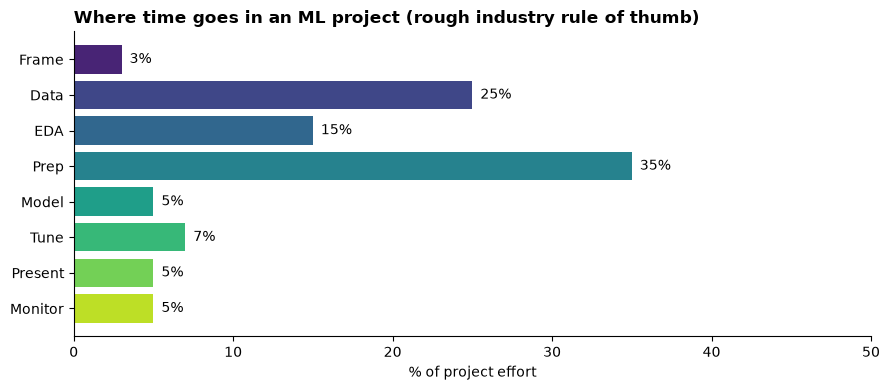

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
stages = ['Frame', 'Data', 'EDA', 'Prep', 'Model', 'Tune', 'Present', 'Monitor']
share  = [3, 25, 15, 35, 5, 7, 5, 5]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(stages)))
ax.barh(stages, share, color=colors)
for i, v in enumerate(share):
    ax.text(v + 0.5, i, f'{v}%', va='center', fontsize=10)
ax.set_xlim(0, 50)
ax.set_xlabel('% of project effort')
ax.set_title('Where time goes in an ML project (rough industry rule of thumb)',
             loc='left', weight='bold')
ax.spines[['top','right']].set_visible(False)
ax.invert_yaxis()
plt.tight_layout(); plt.show()

## 6. Parametric vs nonparametric models

**Parametric** — fix the number of parameters in advance; training only
changes their values.
  Examples: linear regression, logistic regression, linear SVM, MLP with a
  fixed architecture.

**Nonparametric** — number of parameters grows with the data.
  Examples: k-NN, decision tree, kernel SVM, Gaussian process.

| | Parametric | Nonparametric |
|---|---|---|
| Training | cheap | can be expensive (k-NN is O(1), tree is O(n log n)) |
| Inference | O(d) | can be O(n) per prediction |
| Data requirement | small | large |
| Interpretability | high | mixed |
| Asymptotic risk | bounded by model class | approaches Bayes under regularity |

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

knn   = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)
tree  = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_train, y_train)
logit = LogisticRegression(max_iter=200).fit(X_train, y_train)
for name, m in [('k-NN (5)', knn), ('Tree (depth=3)', tree), ('LogReg', logit)]:
    print(f'{name:20s}  test acc = {m.score(X_test, y_test):.3f}')

k-NN (5)              test acc = 0.974
Tree (depth=3)        test acc = 0.895
LogReg                test acc = 0.947


## 7. Why now? — the three forces

ML existed in the 1950s (Perceptron, 1958). It became practical in the 2010s
because three things converged:

1. **Data** — internet-scale labelled datasets (ImageNet 2009, Common Crawl).
2. **Compute** — GPUs (AlexNet 2012), TPUs, cloud.
3. **Algorithms** — backprop + ReLU + dropout + batch norm + Adam +
   self-supervision + transformers.

Each of the three is necessary; none alone is sufficient. When you read about
a new "ML revolution" in a domain, ask which of the three was the bottleneck.

## 8. Reading the rest of the course

Notebook 02 reviews the math (linear algebra, probability, optimization).
Notebook 03 introduces the *statistical learning framework* — the language
in which every later chapter is written (model, loss, risk, bias-variance).
Notebooks 04-08 are the linear / regularization core (ISLR Ch3-6). Notebooks
09-11 are the nonlinear / nonparametric core (ISLR Ch8-12). Notebooks 12-13
are deep learning. Notebook 14 covers advanced topics, and 15 is the
capstone project.

**Suggested reading alongside:** ISLR Ch1 (free online). The Python labs at
the end of each ISLR chapter are gold — do them.

## Summary

| Concept | Key point |
|---|---|
| Mitchell's definition | (T, E, P) triple |
| Taxonomy | Supervised / unsupervised / RL |
| Inductive bias | the model class limits what can be learned |
| Train/test split | held-out data is the only honest evaluation |
| Pipeline | 80% of effort is data, not model |
| Parametric vs nonparametric | fixed-size vs growing-with-data |

**Next:** `02_mathematical_primer.ipynb` — the language of the next 14
chapters.